# Model Selection and Error Analysis for `clarity_results_model_summary.csv`

This notebook does four things:
1. Loads the clarity CV summary table.
2. Identifies the best model by accuracy, macro-F1, and MAE.
3. Rebuilds each selected configuration on the runner train/test split.
4. Shows per-rating accuracy, classification report, confusion matrices, and topic patterns for each metric leader.


In [13]:
import seaborn as sns
import rating_analysis_helpers as rah


sns.set_theme(style='whitegrid')

RESULTS_CSV = 'clarity_results_model_summary.csv'
TARGET_COL = 'clarityRating'

results, cv_summary = rah.load_results_tables(RESULTS_CSV)
metric_leaders = rah.select_metric_leaders(cv_summary)

print(f'Rows: {len(results)}')
print('Result types:', sorted(results['result_type'].dropna().unique().tolist()) if 'result_type' in results.columns else ['unknown'])
results.head()


Rows: 34
Result types: ['cv_summary']


,result_type,k,model,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_mae,std_mae
0,cv_summary,10,hist_gradient_boosting,0.536304,0.005376,0.364047,0.003613,0.820792,0.014187
1,cv_summary,10,xgboost_cls,0.535191,0.005201,0.355042,0.002984,0.835751,0.014210
2,cv_summary,10,stacking_lsvc_logreg_rf,0.532746,0.004973,0.359292,0.003456,0.832225,0.014488
3,cv_summary,8,hist_gradient_boosting,0.531237,0.007488,0.356069,0.004468,0.841685,0.018015
4,cv_summary,8,xgboost_cls,0.529846,0.007215,0.347420,0.004331,0.854841,0.017022


In [14]:
print('Metric leaders from CV summary:')
display(metric_leaders[['selection_label', 'model', 'k', 'mean_accuracy', 'mean_macro_f1', 'mean_mae']])

print('Top 10 CV summary rows by accuracy ranking:')
display(cv_summary.sort_values(['mean_accuracy', 'mean_macro_f1', 'mean_mae'], ascending=[False, False, True])[['model', 'k', 'mean_accuracy', 'mean_macro_f1', 'mean_mae']].head(10))

test_rows = rah.get_optional_test_rows(results)
if test_rows.empty:
    print('No test row found in model summary CSV (expected when runner include_test_row=False).')
else:
    display(test_rows[[c for c in ['model', 'k', 'accuracy', 'macro_f1', 'mae'] if c in test_rows.columns]])


Metric leaders from CV summary:


,selection_label,model,k,mean_accuracy,mean_macro_f1,mean_mae
0,Best by Accuracy,hist_gradient_boosting,10,0.536304,0.364047,0.820792
1,Best by Macro-F1,random_forest_cls,8,0.505031,0.403277,0.819118
2,Best by MAE,random_forest_cls,10,0.514135,0.402962,0.803607


Top 10 CV summary rows by accuracy ranking:


,model,k,mean_accuracy,mean_macro_f1,mean_mae
0,hist_gradient_boosting,10,0.536304,0.364047,0.820792
1,xgboost_cls,10,0.535191,0.355042,0.835751
2,stacking_lsvc_logreg_rf,10,0.532746,0.359292,0.832225
3,hist_gradient_boosting,8,0.531237,0.356069,0.841685
4,xgboost_cls,8,0.529846,0.347420,0.854841
5,stacking_lsvc_logreg_rf,8,0.528730,0.349771,0.852704
6,bagging_linear,10,0.517488,0.314306,0.928115
7,multinomial_logreg,10,0.517475,0.315814,0.926802
8,hist_gradient_boosting,5,0.516623,0.336277,0.906224
9,stacking_lsvc_logreg_rf,5,0.516612,0.332583,0.909450


No test row found in model summary CSV (expected when runner include_test_row=False).


## Rebuild and analyze each metric leader

The next cells reconstruct the same train/test split and feature pipeline used by the runner, then repeat the full downstream analysis for the best-by-accuracy, best-by-macro-F1, and best-by-MAE configurations.


In [15]:
state = rah.build_analysis_state(target_col=TARGET_COL)

print(f"Train rows: {len(state['df_train']):,}")
print(f"Test rows: {len(state['df_test']):,}")
print(f"Tag columns: {len(state['tag_cols'])}")


Train rows: 371,021
Test rows: 86,936
Tag columns: 27


## Best by Accuracy

Selected CV summary row:


,value
model,hist_gradient_boosting
k,10
mean_accuracy,0.536304
mean_macro_f1,0.364047
mean_mae,0.820792


Rebuilt model: hist_gradient_boosting (k=10)
Holdout accuracy: 0.5481
Holdout macro F1: 0.3738
Holdout MAE: 0.7792
Per-rating accuracy (conditioned on true class):


,true_rating,support,correct_predictions,accuracy_when_true
0,1,14279,10689,0.748582
1,2,9084,768,0.084544
2,3,10092,951,0.094233
3,4,16451,3494,0.212388
4,5,37030,31745,0.857278


Classification report:
              precision    recall  f1-score   support

           1     0.5050    0.7486    0.6031     14279
           2     0.2699    0.0845    0.1288      9084
           3     0.2648    0.0942    0.1390     10092
           4     0.3183    0.2124    0.2548     16451
           5     0.6565    0.8573    0.7436     37030

    accuracy                         0.5481     86936
   macro avg     0.4029    0.3994    0.3738     86936
weighted avg     0.4817    0.5481    0.4936     86936



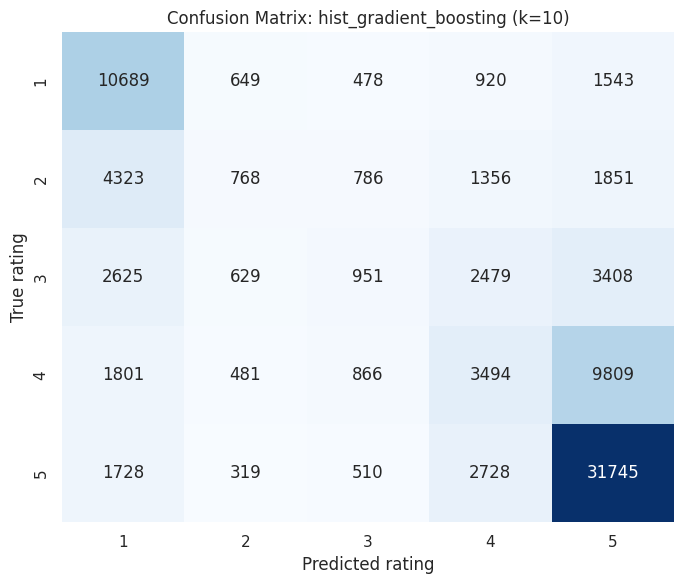

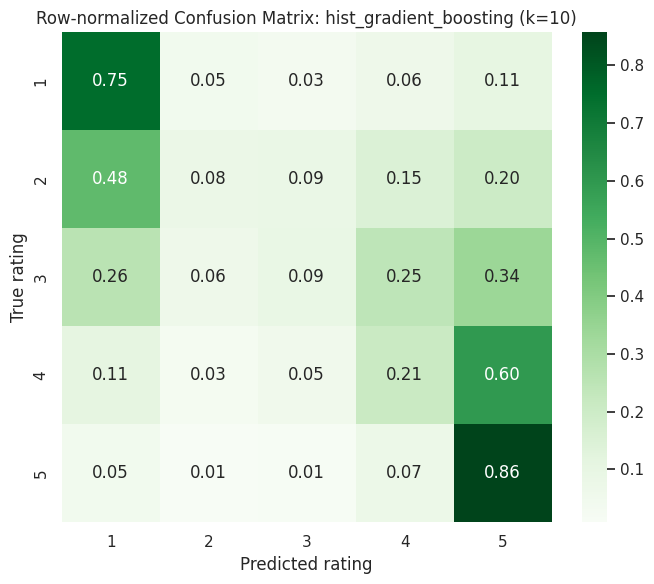

Topic-level descriptive patterns:


,topic,support,mean_rating,top_words
0,7,23253,4.593601,"best, best professor, professor, professors, b..."
1,9,23783,4.522558,"great, great professor, professor, great teach..."
2,5,32433,4.352943,"interesting, easy, class, recommend, fun, high..."
3,1,31170,4.086718,"students, cares, cares students, really cares,..."
4,3,22825,3.936342,"office, hours, office hours, helpful, helpful ..."
5,6,23289,3.797243,"good, teacher, good teacher, good professor, r..."
6,2,24937,3.646188,"nice, guy, nice guy, really, really nice, funn..."
7,4,53520,3.531895,"final, midterm, midterm final, grade, quizzes,..."
8,0,57111,3.360193,"tests, lecture, lectures, exams, hard, questio..."
9,8,78700,2.578539,"class, don, like, just, time, know, teaching, ..."


## Best by Macro-F1

Selected CV summary row:


,value
model,random_forest_cls
k,8
mean_accuracy,0.505031
mean_macro_f1,0.403277
mean_mae,0.819118


Rebuilt model: random_forest_cls (k=8)
Holdout accuracy: 0.5117
Holdout macro F1: 0.4052
Holdout MAE: 0.8058
Per-rating accuracy (conditioned on true class):


,true_rating,support,correct_predictions,accuracy_when_true
0,1,14279,9400,0.658309
1,2,9084,1894,0.208498
2,3,10092,2117,0.209770
3,4,16451,4581,0.278463
4,5,37030,26495,0.715501


Classification report:
              precision    recall  f1-score   support

           1     0.5003    0.6583    0.5685     14279
           2     0.2269    0.2085    0.2173      9084
           3     0.2281    0.2098    0.2185     10092
           4     0.3165    0.2785    0.2963     16451
           5     0.7351    0.7155    0.7252     37030

    accuracy                         0.5117     86936
   macro avg     0.4014    0.4141    0.4052     86936
weighted avg     0.5054    0.5117    0.5064     86936



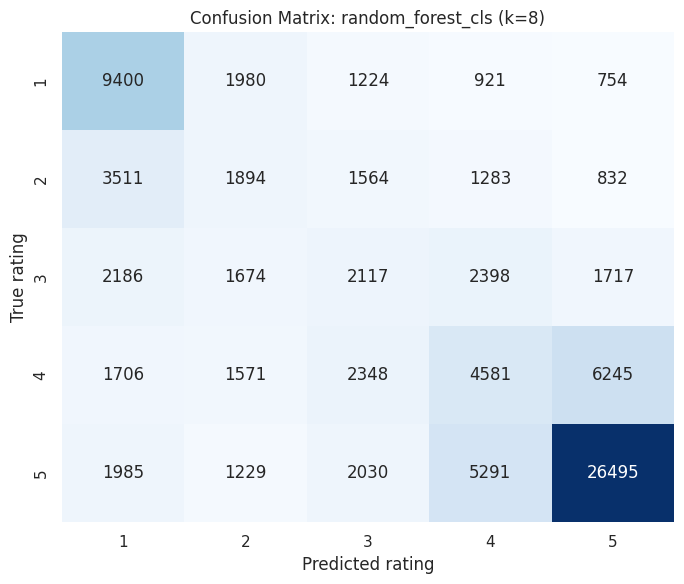

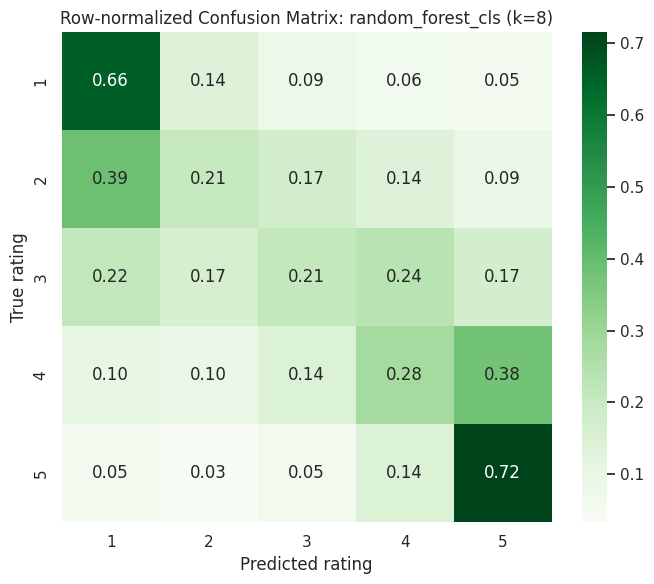

Topic-level descriptive patterns:


,topic,support,mean_rating,top_words
0,5,20672,4.480553,"great, great professor, professor, great teach..."
1,7,24533,4.432153,"best, best professor, professor, professors, b..."
2,2,86745,3.983134,"class, interesting, easy, recommend, really, l..."
3,3,23544,3.894028,"office, hours, office hours, helpful, helpful ..."
4,1,35647,3.804472,"students, cares, cares students, really cares,..."
5,6,29134,3.635134,"good, teacher, good teacher, good professor, r..."
6,4,63996,3.472061,"final, midterm, midterm final, grade, quizzes,..."
7,0,86750,2.694282,"hard, tests, lecture, lectures, just, exams, d..."


## Best by MAE

Selected CV summary row:


,value
model,random_forest_cls
k,10
mean_accuracy,0.514135
mean_macro_f1,0.402962
mean_mae,0.803607


Rebuilt model: random_forest_cls (k=10)
Holdout accuracy: 0.5273
Holdout macro F1: 0.4108
Holdout MAE: 0.7651
Per-rating accuracy (conditioned on true class):


,true_rating,support,correct_predictions,accuracy_when_true
0,1,14279,9750,0.682821
1,2,9084,1714,0.188683
2,3,10092,2021,0.200258
3,4,16451,4578,0.278281
4,5,37030,27781,0.750230


Classification report:
              precision    recall  f1-score   support

           1     0.5181    0.6828    0.5892     14279
           2     0.2345    0.1887    0.2091      9084
           3     0.2396    0.2003    0.2182     10092
           4     0.3270    0.2783    0.3007     16451
           5     0.7240    0.7502    0.7369     37030

    accuracy                         0.5273     86936
   macro avg     0.4086    0.4201    0.4108     86936
weighted avg     0.5077    0.5273    0.5147     86936



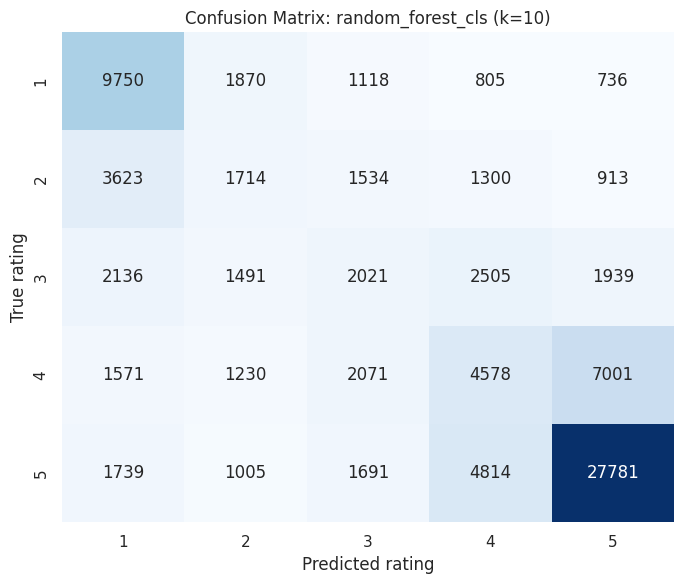

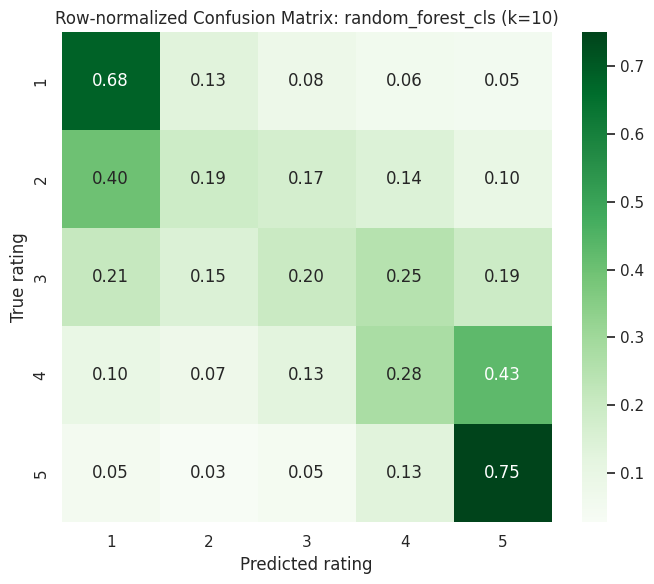

Topic-level descriptive patterns:


,topic,support,mean_rating,top_words
0,7,23253,4.593601,"best, best professor, professor, professors, b..."
1,9,23783,4.522558,"great, great professor, professor, great teach..."
2,5,32433,4.352943,"interesting, easy, class, recommend, fun, high..."
3,1,31170,4.086718,"students, cares, cares students, really cares,..."
4,3,22825,3.936342,"office, hours, office hours, helpful, helpful ..."
5,6,23289,3.797243,"good, teacher, good teacher, good professor, r..."
6,2,24937,3.646188,"nice, guy, nice guy, really, really nice, funn..."
7,4,53520,3.531895,"final, midterm, midterm final, grade, quizzes,..."
8,0,57111,3.360193,"tests, lecture, lectures, exams, hard, questio..."
9,8,78700,2.578539,"class, don, like, just, time, know, teaching, ..."


In [16]:
analysis_results = rah.run_metric_leader_analysis(metric_leaders, state)
